# Phần 2 — Inverting Gradients trên ResNet-18 (ImageNet), kèm DP-SGD defense

**Pillar:** Security — privacy trong Federated Learning (FL).

**Claim under test:** *"In Federated Learning, raw data never leaves the device — only gradients are shared."*
Phần 1 cho thấy DLG/iDLG khôi phục được ảnh từ gradient của một LeNet nhỏ (Sigmoid, không BatchNorm). Phần 2 kiểm tra cùng claim ở quy mô thực tế hơn: **ResNet-18** (ReLU + BatchNorm + skip-connection, 11.7M tham số) trên **ảnh ImageNet 224×224**, chỉ từ gradient của **một client (batch size = 1)**.

**Contents:**
1. **Inverting Gradients** (Geiping, Bauermeister, Dröge, Moeller, NeurIPS 2020) — thay cost $\ell_2$ của DLG bằng **cosine similarity** giữa gradient, tối ưu bằng **signed Adam** kết hợp **total variation**, **box constraint**, **lr decay**, **median filter** và **nhiều restart** để tránh local minimum. Code dùng package `inversefed` của Geiping et al. (https://github.com/JonasGeiping/invertinggradients), đặt trong thư mục [inversefed/](inversefed/).
2. **DP-SGD defense** (Abadi et al., 2016) — clip L2 norm của gradient rồi cộng Gaussian noise *trước khi* chia sẻ, để đo mức protection mà nó mang lại; dùng cùng dải noise multiplier $\sigma$ như Phần 1.

**Model:** `torchvision.models.resnet18`, **khởi tạo ngẫu nhiên và chưa train**, ở chế độ `eval()`. Cùng threat model với Phần 1: attacker (server hoặc eavesdropper) quan sát gradient ở **những round FL đầu tiên**, khi model chưa được train.
**Dataset:** ImageNet, ảnh validation, mỗi lần một ảnh.

In [1]:
import torch
import torchvision

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from PIL import Image

# Choose variants here:

## 1. Chọn model

- `trained_model = False`: dùng ResNet-18 **chưa train** (`pretrained=False`), tức trọng số là khởi tạo ngẫu nhiên mặc định của torchvision. Đặt `True` sẽ dùng trọng số đã train trên ImageNet.
- `arch` chỉ dùng để đặt tên các file ảnh được lưu ra.

Model chưa train phù hợp với threat model đã nêu (attacker quan sát ở các round FL đầu). Ở trạng thái này model gần như đoán ngẫu nhiên ($p_{true} \approx 1/1000$, loss $\approx \ln 1000 \approx 6.9$), nên gradient lớn và mang nhiều thông tin về ảnh đầu vào.

In [2]:
trained_model = False
arch = 'ResNet18'

## System setup:

## 2. Thiết lập hệ thống và dữ liệu

`inversefed.utils.system_startup()` chọn GPU và trả về `setup` (device, dtype). `inversefed.training_strategy('conservative')` chỉ cung cấp các tham số của pipeline dữ liệu (batch size, augmentation).

**Dữ liệu.** ImageNet đầy đủ (~150 GB) không có sẵn, nên dùng **4 ảnh validation** lấy từ https://github.com/EliSchwartz/imagenet-sample-images (beagle, great grey owl, German shepherd, giant panda). Lớp `SampleImageNet` đưa chúng qua đúng pipeline validation của ImageNet: `Resize(256) → CenterCrop(224) → ToTensor → Normalize(imagenet_mean, imagenet_std)`, và loss là `Classification()` (cross-entropy chuẩn) của `inversefed`.
Nếu đã có ImageNet cục bộ, đặt `IMAGENET_ROOT` ở cell *System setup* để dùng `inversefed.construct_dataloaders('ImageNet', ...)` trên dữ liệu thật; khi đó `idx = 8112` chọn ảnh beagle từ tập validation.

In [3]:
import os, urllib.request
from torchvision import transforms
import inversefed

class SampleImageNet(torch.utils.data.Dataset):
    # Stand-in for the ImageNet validation set: a few images, same preprocessing as inversefed's _build_imagenet (val, no augmentation).
    FILES = [("n02088364_beagle.JPEG", 162), ("n01622779_great_grey_owl.JPEG", 24),
             ("n02106662_German_shepherd.JPEG", 235), ("n02510455_giant_panda.JPEG", 388)]   # (file, ImageNet-1k class index)
    BASE = "https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/"

    def __init__(self, root="./data"):
        os.makedirs(root, exist_ok=True)
        self.paths = []
        for fname, _ in self.FILES:
            path = os.path.join(root, fname)
            if not os.path.exists(path):
                urllib.request.urlretrieve(self.BASE + fname, path)
            self.paths.append(path)
        self.classes = [(name,) for name in torchvision.models.ResNet18_Weights.IMAGENET1K_V1.meta["categories"]]
        self.transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(inversefed.consts.imagenet_mean, inversefed.consts.imagenet_std)])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), self.FILES[i][1]

def sample_dataloaders():
    dataset = SampleImageNet()
    loader = torch.utils.data.DataLoader(dataset, batch_size=1)
    return inversefed.data.loss.Classification(), loader, loader   # loss_fn, trainloader, validloader

In [4]:
import inversefed
setup = inversefed.utils.system_startup()
defs = inversefed.training_strategy('conservative')

IMAGENET_ROOT = None   # e.g. '/data/imagenet' to use the real ImageNet instead of the 4 sample images
if IMAGENET_ROOT is not None:
    loss_fn, trainloader, validloader =  inversefed.construct_dataloaders('ImageNet', defs, 
                                                                          data_path=IMAGENET_ROOT)
else:
    loss_fn, trainloader, validloader = sample_dataloaders()

model = torchvision.models.resnet18(pretrained=trained_model)
model.to(**setup)
model.eval()

Currently evaluating -------------------------------:
Sunday, 20. September 2026 06:13PM
CPUs: 10, GPUs: 1 on DESKTOP-DF030H0.
GPU : NVIDIA GeForce RTX 5060 Ti


e:\anaconda3\envs\python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\anaconda3\envs\python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Hằng số normalize và hàm hiển thị

- `dm`, `ds` (mean, std theo kênh) xác định **box constraint**: sau mỗi bước tối ưu, ảnh reconstruct được chiếu về khoảng giá trị hợp lệ $[(0 - dm)/ds,\ (1 - dm)/ds]$ tương ứng với pixel trong $[0, 1]$. Ở đây `dm`, `ds` lấy từ `inversefed.consts.cifar10_mean/std`; ảnh đầu vào được normalize bằng thống kê ImageNet ở bước dữ liệu, nên hai bộ thống kê này gần nhau nhưng không trùng.
- `plot(tensor)` đảo normalize (`tensor * ds + dm`, clamp về $[0, 1]$) rồi hiển thị ảnh.

In [5]:
dm = torch.as_tensor(inversefed.consts.cifar10_mean, **setup)[:, None, None]
ds = torch.as_tensor(inversefed.consts.cifar10_std, **setup)[:, None, None]
def plot(tensor):
    tensor = tensor.clone().detach()
    tensor.mul_(ds).add_(dm).clamp_(0, 1)
    if tensor.shape[0] == 1:
        return plt.imshow(tensor[0].permute(1, 2, 0).cpu())
    else:
        fig, axes = plt.subplots(1, tensor.shape[0], figsize=(12, tensor.shape[0]*12))
        for i, im in enumerate(tensor):
            axes[i].imshow(im.permute(1, 2, 0).cpu())

# Reconstruct

### Build the input (ground-truth) gradient

## 3. Gradient của client

Client (honest participant) tính gradient cục bộ trên ảnh private $(x, y)$ với cross-entropy chuẩn rồi gửi cho server:

$$\Delta w = \nabla_\theta\,\mathcal{L}\big(f_\theta(x),\, y\big)$$

Attacker chỉ quan sát $\Delta w$ (`input_gradient`), không thấy $(x, y)$, nhưng biết kiến trúc và trọng số hiện tại của model — điều mà server trong FL luôn có. Mục tiêu: dựng lại $x$ từ $\Delta w$.

`idx` chọn ảnh của client: với 4 ảnh mẫu, `0` = beagle, `1` = owl, `2` = German shepherd, `3` = panda.

[('beagle',)]


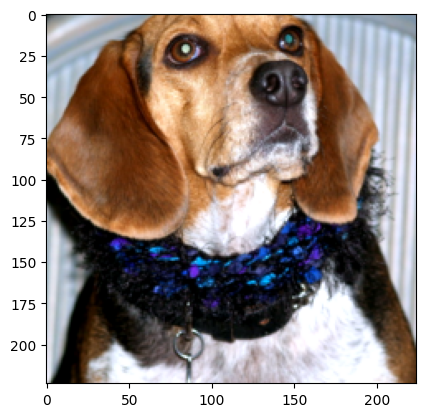

In [6]:
idx = 8112 if IMAGENET_ROOT is not None else 0   # sample set: 0 = beagle, 1 = owl, 2 = German shepherd, 3 = panda
# 8112 # the beagle
# 1200 # the owl
# 11794 # the German shepherd
# 19449 # the panda


# np.random.randint(len(validloader.dataset))

img, label = validloader.dataset[idx]
labels = torch.as_tensor((label,), device=setup['device'])
ground_truth = img.to(**setup).unsqueeze(0)
plot(ground_truth)
print([trainloader.dataset.classes[l] for l in labels])

In [7]:
ground_truth_denormalized = torch.clamp(ground_truth * ds + dm, 0, 1)

Cell dưới tính gradient của cross-entropy theo toàn bộ **62 tensor tham số** của ResNet-18 (11 689 512 tham số) và lưu vào `input_gradient` (đã `detach`). In ra `full_norm`, trung bình norm của từng tensor gradient, để nắm độ lớn của tín hiệu mà attacker có.

In [8]:
model.zero_grad()
target_loss, _, _ = loss_fn(model(ground_truth), labels)
input_gradient = torch.autograd.grad(target_loss, model.parameters())
input_gradient = [grad.detach() for grad in input_gradient]
full_norm = torch.stack([g.norm() for g in input_gradient]).mean()
print(f'Full gradient norm is {full_norm:e}.')

Full gradient norm is 3.409002e+00.


## 4. Inverting Gradients — reconstruct ảnh từ gradient

Attacker tìm ảnh $x'$ sao cho **hướng** gradient của nó trùng với gradient bị leak $\Delta w$ (`cost_fn='sim'`):

$$x^{*} = \arg\min_{x'} \;\; 1 - \frac{\big\langle \nabla_\theta\mathcal{L}(f_\theta(x'), y),\; \Delta w\big\rangle}{\big\lVert \nabla_\theta\mathcal{L}(f_\theta(x'), y)\big\rVert_2 \,\big\lVert \Delta w \big\rVert_2} \;+\; \alpha\,\mathrm{TV}(x')$$

So với DLG ở Phần 1: cost dùng **cosine** thay vì $\ell_2$, nên chỉ so sánh *hướng* của gradient và không phụ thuộc vào độ lớn của nó; ảnh được tối ưu bằng **Adam trên dấu của gradient** (kỹ thuật lấy từ adversarial attacks) thay vì L-BFGS. Vì cost là hàm của $\nabla_\theta\mathcal L$, tính đạo hàm theo $x'$ cần **double backprop**, như ở Phần 1.

Các tham số của `config`:

| Tham số | Giá trị | Ý nghĩa |
|---|---|---|
| `cost_fn` | `'sim'` | cost cosine similarity |
| `indices` | `'top10'` | chỉ 10 tensor gradient có norm lớn nhất tham gia vào cost |
| `weights` | `'equal'` | các tensor được cộng với trọng số bằng nhau |
| `optim`, `lr` | `'adam'`, `0.1` | optimizer và learning rate ban đầu |
| `signed` | `True` | dùng **dấu** của gradient theo $x'$ làm hướng cập nhật |
| `boxed` | `True` | sau mỗi bước, chiếu $x'$ về khoảng giá trị hợp lệ của ảnh |
| `total_variation` | `1e-6` | trọng số $\alpha$ của total variation prior (mean của $\lvert$chênh lệch giữa pixel kề nhau$\rvert$) |
| `filter` | `'median'` | median filter 3×3 áp dụng mỗi 500 iterations |
| `lr_decay` | `True` | lr nhân 0.1 tại $3/8$, $5/8$ và $7/8$ số iteration |
| `max_iterations` | `24_000` | số iteration của mỗi restart |
| `restarts` | `4` | số lần chạy độc lập từ các ảnh noise khác nhau |
| `init` | `'randn'` | ảnh khởi tạo là Gaussian noise |
| `scoring_choice` | `'loss'` | chọn restart có cost (không tính TV) nhỏ nhất |

**Restart.** Bài toán không lồi nên mỗi ảnh khởi tạo có thể hội tụ về một local minimum khác nhau; chạy nhiều restart rồi chọn kết quả có cost nhỏ nhất làm kết quả ổn định hơn. Score chỉ cần gradient bị leak và model, nên attacker tự chọn được mà không cần biết ảnh gốc.
Label $y$ được đưa vào `reconstruct` (`labels`). Trong lúc chạy, thư viện in `Rec. loss` mỗi 500 iterations của từng restart.

It: 0. Rec. loss: 0.0410.
It: 500. Rec. loss: 0.0271.
It: 1000. Rec. loss: 0.0193.
It: 1500. Rec. loss: 0.0157.
It: 2000. Rec. loss: 0.0152.
It: 2500. Rec. loss: 0.0147.
It: 3000. Rec. loss: 0.0137.
It: 3500. Rec. loss: 0.0134.
It: 4000. Rec. loss: 0.0132.
It: 4500. Rec. loss: 0.0133.
It: 5000. Rec. loss: 0.0133.
It: 5500. Rec. loss: 0.0129.
It: 6000. Rec. loss: 0.0131.
It: 6500. Rec. loss: 0.0125.
It: 7000. Rec. loss: 0.0131.
It: 7500. Rec. loss: 0.0125.
It: 8000. Rec. loss: 0.0122.
It: 8500. Rec. loss: 0.0131.
It: 9000. Rec. loss: 0.0129.
It: 9500. Rec. loss: 0.0113.
It: 10000. Rec. loss: 0.0093.
It: 10500. Rec. loss: 0.0088.
It: 11000. Rec. loss: 0.0076.
It: 11500. Rec. loss: 0.0071.
It: 12000. Rec. loss: 0.0070.
It: 12500. Rec. loss: 0.0063.
It: 13000. Rec. loss: 0.0061.
It: 13500. Rec. loss: 0.0064.
It: 14000. Rec. loss: 0.0059.
It: 14500. Rec. loss: 0.0056.
It: 15000. Rec. loss: 0.0053.
It: 15500. Rec. loss: 0.0050.
It: 16000. Rec. loss: 0.0045.
It: 16500. Rec. loss: 0.0044.
It: 

Text(0.5, 0.98, 'Error between layers')

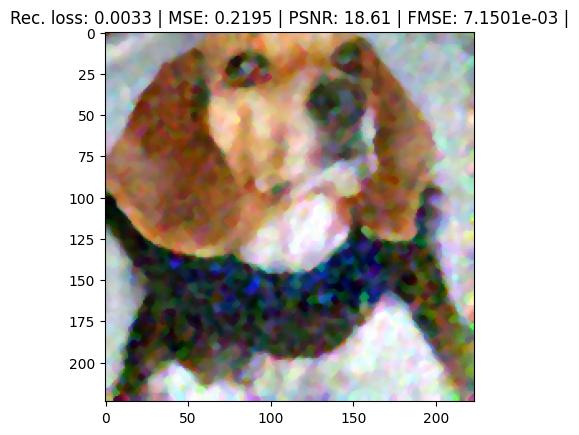

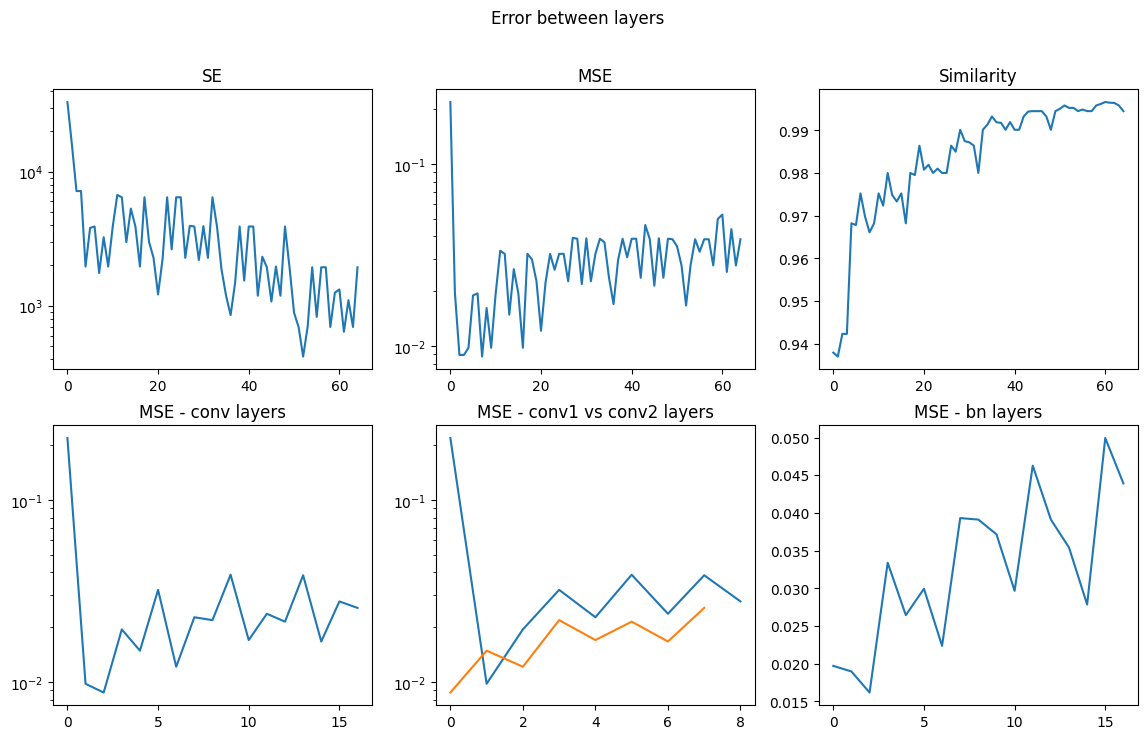

In [9]:
config = dict(signed=True,
              boxed=True,
              cost_fn='sim',
              indices='top10',
              weights='equal',
              lr=0.1,
              optim='adam',
              restarts=2,
              max_iterations=24_000,
              total_variation=1e-6,
              init='randn',
              filter='median',
              lr_decay=True,
              scoring_choice='loss')

rec_machine = inversefed.GradientReconstructor(model, (dm, ds), config, num_images=1)
output, stats = rec_machine.reconstruct(input_gradient, labels, img_shape=(3, 224, 224))

test_mse = (output.detach() - ground_truth).pow(2).mean()
feat_mse = (model(output.detach())- model(ground_truth)).pow(2).mean()  
test_psnr = inversefed.metrics.psnr(output, ground_truth, factor=1/ds)

plot(output)
plt.title(f"Rec. loss: {stats['opt']:2.4f} | MSE: {test_mse:2.4f} "
          f"| PSNR: {test_psnr:4.2f} | FMSE: {feat_mse:2.4e} |")

data = inversefed.metrics.activation_errors(model, output, ground_truth)

fig, axes = plt.subplots(2, 3, sharey=False, figsize=(14,8))
axes[0, 0].semilogy(list(data['se'].values())[:-3])
axes[0, 0].set_title('SE')
axes[0, 1].semilogy(list(data['mse'].values())[:-3])
axes[0, 1].set_title('MSE')
axes[0, 2].plot(list(data['sim'].values())[:-3])
axes[0, 2].set_title('Similarity')

convs = [val for key, val in data['mse'].items() if 'conv' in key]
axes[1, 0].semilogy(convs)
axes[1, 0].set_title('MSE - conv layers')
convs = [val for key, val in data['mse'].items() if 'conv1' in key]
axes[1, 1].semilogy(convs)
convs = [val for key, val in data['mse'].items() if 'conv2' in key]
axes[1, 1].semilogy(convs)
axes[1, 1].set_title('MSE - conv1 vs conv2 layers')
bns = [val for key, val in data['mse'].items() if 'bn' in key]
axes[1, 2].plot(bns)
axes[1, 2].set_title('MSE - bn layers')
fig.suptitle('Error between layers')

### Kết quả reconstruct

Cell trước in `Rec. loss` của restart tốt nhất và vẽ ảnh reconstruct cùng các metric:

- **MSE**: sai số bình phương trung bình giữa ảnh reconstruct và ảnh gốc, trong không gian đã normalize.
- **PSNR** (dB): $10\log_{10}(\text{peak}^2/\mathrm{MSE})$ với peak $= 1/ds$ (khoảng giá trị của ảnh sau normalize); PSNR càng cao thì ảnh reconstruct càng giống ảnh gốc.
- **FMSE**: MSE giữa *logits* của model trên ảnh reconstruct và trên ảnh gốc, đo mức độ giống nhau *theo góc nhìn của model*.
- Ba biểu đồ hàng dưới (`metrics.activation_errors`) so sánh **input của từng module** giữa hai ảnh: SE, MSE, cosine similarity theo từng lớp, và riêng cho các lớp conv, conv1/conv2 và BatchNorm. Sai số nhỏ ở các lớp sâu nghĩa là hai ảnh gần như không phân biệt được đối với model.

In [10]:
output_denormalized = torch.clamp(output * ds + dm, 0, 1)

### Ground truth và ảnh reconstruct

Đặt ảnh gốc của client cạnh ảnh attacker khôi phục được từ gradient, kèm các metric ở trên.

C:\Users\Admin\AppData\Local\Temp\ipykernel_18388\988113871.py:8: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  axes[1].set_title("reconstruction from gradient\nMSE %.4f | PSNR %.2f dB | FMSE %.2e" % (test_mse, test_psnr, feat_mse))


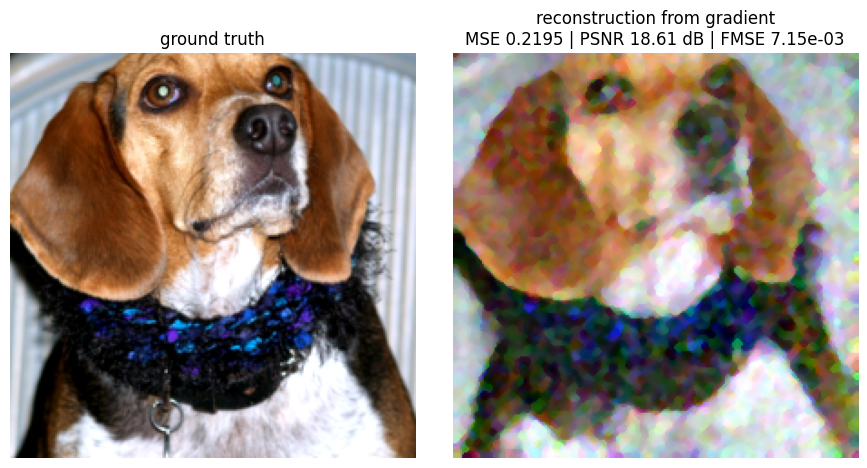

In [11]:
def to_img(tensor):
    # same de-normalisation as plot(), returns HxWx3 in [0, 1]
    return (tensor.clone().detach().to(ds.device) * ds + dm).clamp(0, 1)[0].permute(1, 2, 0).cpu()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.6))
axes[0].imshow(to_img(ground_truth)); axes[0].set_title("ground truth"); axes[0].axis("off")
axes[1].imshow(to_img(output)); axes[1].axis("off")
axes[1].set_title("reconstruction from gradient\nMSE %.4f | PSNR %.2f dB | FMSE %.2e" % (test_mse, test_psnr, feat_mse))
plt.tight_layout(); plt.show()

## 5. DP-SGD defense — gradient clipping + Gaussian noise (Abadi et al., 2016)

Defense được áp dụng **ở phía client, trước khi gradient rời thiết bị**, giống Phần 1: clip L2 norm toàn cục của gradient về ngưỡng $C$, rồi cộng Gaussian noise với noise multiplier $\sigma$:

$$\tilde{g} = \mathrm{clip}(g, C) + \mathcal{N}\!\left(0,\; (\sigma C)^2 I\right), \qquad \mathrm{clip}(g, C) = g \cdot \min\!\left(1, \tfrac{C}{\lVert g\rVert_2}\right)$$

Attacker chạy Inverting Gradients với **đúng cấu hình `config` ở mục 4** trên gradient đã bị biến đổi $\tilde g$, và **không biết label**: với `labels=None`, `GradientReconstructor` tự recover label bằng iDLG từ chính $\tilde g$ (cột `label_correct` cho biết label đó có đúng không).

**Lưới $(C, \sigma)$.** $\sigma \in \{0, 10^{-4}, 10^{-3}, 10^{-2}\}$ giữ nguyên như Phần 1. Gradient của ResNet-18 có norm lớn hơn LeNet nhiều, nên $C$ được đặt theo global norm của gradient gốc với **cùng tỉ lệ $C/\lVert g\rVert \approx 0.36$ và $1.07$ như Phần 1** ($C = 10, 30$ khi $\lVert g\rVert \approx 28$): $C \approx 1.07\lVert g\rVert$ hầu như không clip gì, còn $C \approx 0.36\lVert g\rVert$ thu nhỏ gradient khoảng 2.8 lần.

Hai điểm cần lưu ý khi đọc kết quả:

1. **Clipping chỉ nhân gradient với một hằng số dương**, nên cosine cost **bất biến** với clipping (khác cost $\ell_2$ của DLG). Clipping chỉ tác động *gián tiếp*: noise có độ lệch chuẩn $\sigma C$ chứ không tỉ lệ với $\lVert g\rVert$, nên $C$ làm thay đổi tỉ lệ *signal : noise*.
2. Gradient có $d \approx 1.17 \times 10^{7}$ chiều nên norm của noise $\approx \sigma C\sqrt{d} \approx 3400\,\sigma C$. Đại lượng `grad_cos` = cosine giữa gradient đã defend và gradient gốc đo trực tiếp "lượng tín hiệu còn lại" mà cost cosine có thể bám vào.

**Ngân sách tính toán.** Để 8 cấu hình chạy trong thời gian hợp lý, mỗi cấu hình dùng `DEFENSE_ITERS = 4 800` iterations và `DEFENSE_RESTARTS = 1` restart (ít hơn `24_000 × 4` của mục 4); mọi tham số khác của `config` giữ nguyên. Hàng $\sigma = 0$ là baseline không có noise dưới cùng ngân sách, dùng để đối chiếu.

In [12]:
DEFENSE_ITERS, DEFENSE_RESTARTS = 4_800, 1                                   # budget per configuration (main run: 24_000 x 4)
defense_config = dict(config, restarts=DEFENSE_RESTARTS, max_iterations=DEFENSE_ITERS)

def global_norm(grads):
    return torch.sqrt(sum((g ** 2).sum() for g in grads)).item()

def dp_sgd_defense(grads, C, sigma):
    # client side: clip the global L2 norm to C, then add N(0, (sigma * C)^2) to every entry
    coef = min(1.0, C / (global_norm(grads) + 1e-6))
    return [g * coef + torch.randn_like(g) * sigma * C for g in grads]

def grad_cosine(a, b):
    return (sum((x * y).sum() for x, y in zip(a, b)) / (global_norm(a) * global_norm(b))).item()

total_norm = global_norm(input_gradient)
clip_norms = [round(r * total_norm, 1) for r in (0.36, 1.07)]                 # same C / ||g|| ratios as Part 1
noise_stds = [0.0, 1e-4, 1e-3, 1e-2]
print("Global L2 norm of the original gradient: %.4f | clip norms C: %s" % (total_norm, clip_norms))

defense_results = []
for C in clip_norms:
    for sigma in noise_stds:
        defended = dp_sgd_defense(input_gradient, C, sigma)
        label_pred = torch.argmin(torch.sum(defended[-2], dim=-1), dim=-1)      # what the attacker's iDLG step will recover
        print("\n[%d/%d] C=%s, sigma=%s" % (len(defense_results) + 1, len(clip_norms) * len(noise_stds), C, sigma))

        rec_machine = inversefed.GradientReconstructor(model, (dm, ds), defense_config, num_images=1)
        out, st = rec_machine.reconstruct(defended, None, img_shape=(3, 224, 224))

        res = dict(clip_norm=C, noise_std=sigma, grad_cos=grad_cosine(defended, input_gradient),
                   label_correct=label_pred.item() == labels.item(), rec_loss=st['opt'],
                   mse=(out.detach() - ground_truth).pow(2).mean().item(),
                   psnr=inversefed.metrics.psnr(out, ground_truth, factor=1/ds),
                   fmse=(model(out.detach()) - model(ground_truth)).pow(2).mean().item(), image=out.detach().cpu())
        defense_results.append(res)
        print("   -> grad cos %.3f | label %s | MSE %.4f | PSNR %.2f dB | FMSE %.3e"
              % (res["grad_cos"], "correct" if res["label_correct"] else "WRONG", res["mse"], res["psnr"], res["fmse"]))

import pandas as pd
defense_df = pd.DataFrame(defense_results).drop(columns="image")
defense_df

Global L2 norm of the original gradient: 57.9327 | clip norms C: [20.9, 62.0]

[1/8] C=20.9, sigma=0.0
It: 0. Rec. loss: 0.0379.
It: 500. Rec. loss: 0.0270.
It: 1000. Rec. loss: 0.0185.
It: 1500. Rec. loss: 0.0162.
It: 2000. Rec. loss: 0.0151.
It: 2500. Rec. loss: 0.0136.
It: 3000. Rec. loss: 0.0109.
It: 3500. Rec. loss: 0.0088.
It: 4000. Rec. loss: 0.0079.
It: 4500. Rec. loss: 0.0072.
It: 4799. Rec. loss: 0.0051.
Choosing optimal result ...
Optimal result score: 0.0051
Total time: 131.72828817367554.
   -> grad cos 1.000 | label correct | MSE 0.6946 | PSNR 13.60 dB | FMSE 3.721e-02

[2/8] C=20.9, sigma=0.0001
It: 0. Rec. loss: 0.0911.
It: 500. Rec. loss: 0.0807.
It: 1000. Rec. loss: 0.0707.
It: 1500. Rec. loss: 0.0697.
It: 2000. Rec. loss: 0.0673.
It: 2500. Rec. loss: 0.0658.
It: 3000. Rec. loss: 0.0642.
It: 3500. Rec. loss: 0.0624.
It: 4000. Rec. loss: 0.0615.
It: 4500. Rec. loss: 0.0614.
It: 4799. Rec. loss: 0.0587.
Choosing optimal result ...
Optimal result score: 0.0588
Total time

,clip_norm,noise_std,grad_cos,label_correct,rec_loss,mse,psnr,fmse
0,20.9,0.0000,1.000000,True,0.005147,0.694602,13.603680,0.037214
1,20.9,0.0001,0.946214,True,0.058762,0.831794,12.820885,0.036873
2,20.9,0.0010,0.280933,True,0.721923,1.724253,9.655033,0.191233
3,20.9,0.0100,0.029848,True,0.969237,1.800067,9.468155,0.488897
4,62.0,0.0000,1.000000,True,0.005148,0.706522,13.529787,0.030149
5,62.0,0.0001,0.939117,True,0.066563,0.840048,12.778004,0.040839
6,62.0,0.0010,0.263556,True,0.738809,1.706601,9.699722,0.207913
7,62.0,0.0100,0.027194,True,0.971682,1.819071,9.422547,0.478856


### Chất lượng reconstruction theo noise level

Trục hoành là noise multiplier $\sigma$ (thang `symlog` để hiển thị được $\sigma = 0$), mỗi đường ứng với một clipping threshold $C$; đường nét đứt là kết quả của lần chạy đầy đủ ở mục 4. **PSNR giảm** (hoặc **MSE tăng**) khi $\sigma$ tăng nghĩa là defense hiệu quả hơn. Panel phải là `grad_cos` — mức tín hiệu còn lại trong gradient đã defend.

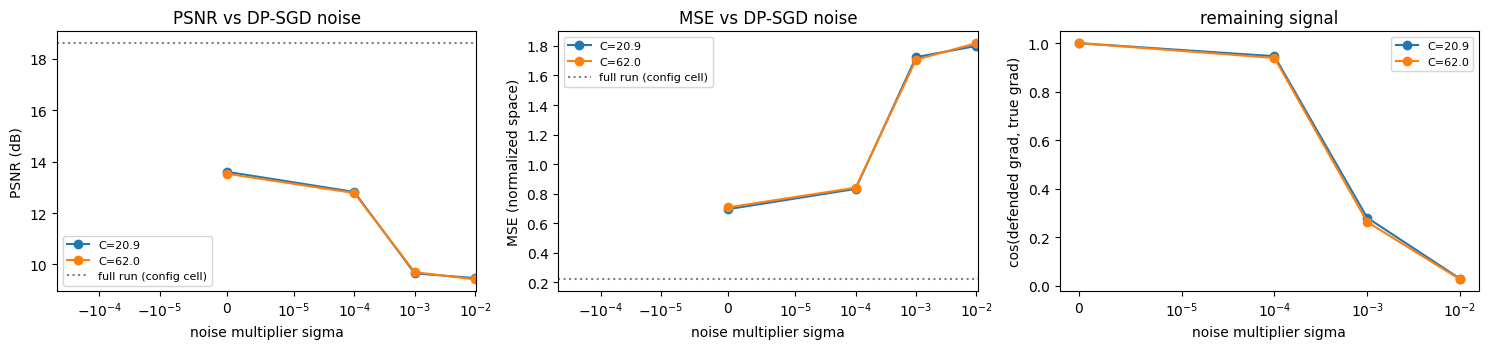

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for C, group in defense_df.groupby("clip_norm"):
    axes[0].plot(group["noise_std"], group["psnr"], marker="o", label="C=%s" % C)
    axes[1].plot(group["noise_std"], group["mse"], marker="o", label="C=%s" % C)
    axes[2].plot(group["noise_std"], group["grad_cos"], marker="o", label="C=%s" % C)
axes[0].axhline(test_psnr, color="gray", ls=":", label="full run (config cell)")
axes[1].axhline(float(test_mse), color="gray", ls=":", label="full run (config cell)")
axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title("PSNR vs DP-SGD noise")
axes[1].set_ylabel("MSE (normalized space)"); axes[1].set_title("MSE vs DP-SGD noise")
axes[2].set_ylabel("cos(defended grad, true grad)"); axes[2].set_title("remaining signal")
for ax in axes:
    ax.set_xscale("symlog", linthresh=1e-5); ax.set_xlabel("noise multiplier sigma"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Ảnh reconstruct theo noise level

Mỗi hàng là một clipping threshold $C$; ô đầu là ground truth, các ô sau là ảnh reconstruct với $\sigma$ tăng dần. Mục đích là xem bằng mắt tại noise level nào ảnh không còn nhận ra được.

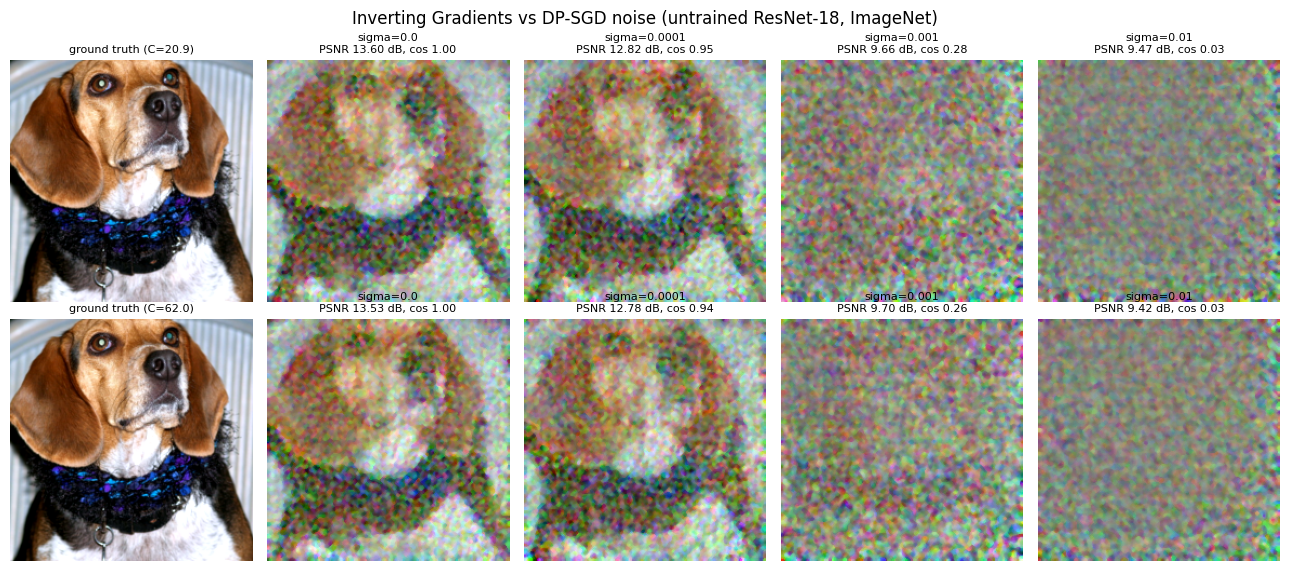

In [14]:
fig, axes = plt.subplots(len(clip_norms), len(noise_stds) + 1, figsize=(2.6 * (len(noise_stds) + 1), 2.9 * len(clip_norms)))
for i, C in enumerate(clip_norms):
    axes[i, 0].imshow(to_img(ground_truth)); axes[i, 0].set_title("ground truth (C=%s)" % C, fontsize=8)
    for j, r in enumerate([r for r in defense_results if r["clip_norm"] == C]):
        axes[i, j + 1].imshow(to_img(r["image"]))
        axes[i, j + 1].set_title("sigma=%s\nPSNR %.2f dB, cos %.2f" % (r["noise_std"], r["psnr"], r["grad_cos"]), fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.suptitle("Inverting Gradients vs DP-SGD noise (untrained ResNet-18, ImageNet)")
plt.tight_layout(); plt.show()